In [1]:
# !wget -O face_landmarker_v2_with_blendshapes.task -q https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
from typing import Tuple, Union
import math
import cv2
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
from mediapipe.tasks.python.vision import drawing_utils
from mediapipe.tasks.python.vision import drawing_styles

In [27]:
train_data = "./affectnet_dataset/train"
test_data = "./affectnet_dataset/test"

In [5]:
classes = sorted([d for d in os.listdir(train_data) if d != '.DS_Store'])
print("Classes: ", classes)

Classes:  ['anger', 'contempt', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [6]:
train_counts = {}
for cls in classes:
    cls_folder = os.path.join(train_data, cls)
    img = [im for im in os.listdir(cls_folder)]
    train_counts[cls] = len(img)
print(train_counts)
print("Total images in training set: ", sum(train_counts.values()))

{'anger': 1500, 'contempt': 1559, 'disgust': 1229, 'fear': 1512, 'happy': 2340, 'neutral': 2758, 'sad': 3091, 'surprise': 2119}
Total images in training set:  16108


In [7]:
test_counts = {}
for cls in classes:
    cls_folder = os.path.join(test_data, cls)
    img = [im for im in os.listdir(cls_folder)]
    test_counts[cls] = len(img)
print(test_counts)
print("Total images in test set: ", sum(test_counts.values()))


{'anger': 1718, 'contempt': 1312, 'disgust': 1248, 'fear': 1664, 'happy': 2704, 'neutral': 2368, 'sad': 1584, 'surprise': 1920}
Total images in test set:  14518


(np.float64(-0.5), np.float64(95.5), np.float64(95.5), np.float64(-0.5))

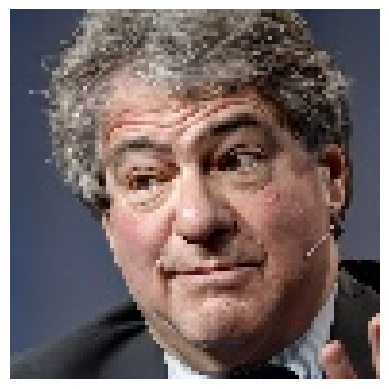

In [8]:
sample_img = cv2.imread(
    os.path.join(
        train_data,
        classes[1],
        os.listdir(os.path.join(train_data, classes[1]))[0]))
sample_img = cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB)
plt.imshow(sample_img)
plt.axis("off")

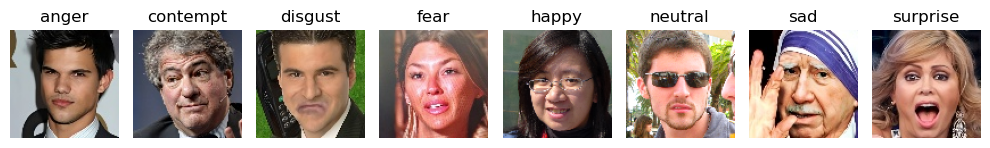

In [9]:
plt.figure(figsize=(10,6))

for i, cls in enumerate(classes):
    class_path = os.path.join(train_data, cls)
    first_img = os.listdir(class_path)[0]
    img_path = os.path.join(class_path, first_img)

    img = cv2.imread(img_path, cv2.IMREAD_COLOR_RGB)

    plt.subplot(1, len(classes), i + 1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis('off')

plt.tight_layout()
plt.show()




In [10]:
sizes = []
for cls in os.listdir(train_data):
    cls_path = os.path.join(train_data, cls)

    if not os.path.isdir(cls_path):
        continue
    for im in os.listdir(cls_path):
        img_path = os.path.join(cls_path, im)

        img = cv2.imread(img_path)
        h, w = img.shape[:2]
        sizes.append((w,h))

print("Img size: ", set(sizes))


Img size:  {(96, 96)}


In [11]:
def draw_landmarks_on_image(rgb_image, detection_result):
  face_landmarks_list = detection_result.face_landmarks
  annotated_image = np.copy(rgb_image)

  # Loop through the detected faces to visualize.
  for idx in range(len(face_landmarks_list)):
    face_landmarks = face_landmarks_list[idx]

    # Draw the face landmarks.


    drawing_utils.draw_landmarks(
        image=annotated_image,
        landmark_list=face_landmarks,
        connections=vision.FaceLandmarksConnections.FACE_LANDMARKS_TESSELATION,
        landmark_drawing_spec=None,
        connection_drawing_spec=drawing_styles.get_default_face_mesh_tesselation_style())
    drawing_utils.draw_landmarks(
        image=annotated_image,
        landmark_list=face_landmarks,
        connections=vision.FaceLandmarksConnections.FACE_LANDMARKS_CONTOURS,
        landmark_drawing_spec=None,
        connection_drawing_spec=drawing_styles.get_default_face_mesh_contours_style())
    drawing_utils.draw_landmarks(
        image=annotated_image,
        landmark_list=face_landmarks,
        connections=vision.FaceLandmarksConnections.FACE_LANDMARKS_LEFT_IRIS,
          landmark_drawing_spec=None,
          connection_drawing_spec=drawing_styles.get_default_face_mesh_iris_connections_style())
    drawing_utils.draw_landmarks(
        image=annotated_image,
        landmark_list=face_landmarks,
        connections=vision.FaceLandmarksConnections.FACE_LANDMARKS_RIGHT_IRIS,
          landmark_drawing_spec=None,
          connection_drawing_spec=drawing_styles.get_default_face_mesh_iris_connections_style())

  return annotated_image

def plot_face_blendshapes_bar_graph(face_blendshapes):
  # Extract the face blendshapes category names and scores.
  face_blendshapes_names = [face_blendshapes_category.category_name for face_blendshapes_category in face_blendshapes]
  face_blendshapes_scores = [face_blendshapes_category.score for face_blendshapes_category in face_blendshapes]
  # The blendshapes are ordered in decreasing score value.
  face_blendshapes_ranks = range(len(face_blendshapes_names))

  fig, ax = plt.subplots(figsize=(12, 12))
  bar = ax.barh(face_blendshapes_ranks, face_blendshapes_scores, label=[str(x) for x in face_blendshapes_ranks])
  ax.set_yticks(face_blendshapes_ranks, face_blendshapes_names)
  ax.invert_yaxis()

  # Label each bar with values
  for score, patch in zip(face_blendshapes_scores, bar.patches):
    plt.text(patch.get_x() + patch.get_width(), patch.get_y(), f"{score:.4f}", va="top")

  ax.set_xlabel('Score')
  ax.set_title("Face Blendshapes")
  plt.tight_layout()
  plt.show()

(np.float64(-0.5), np.float64(95.5), np.float64(95.5), np.float64(-0.5))

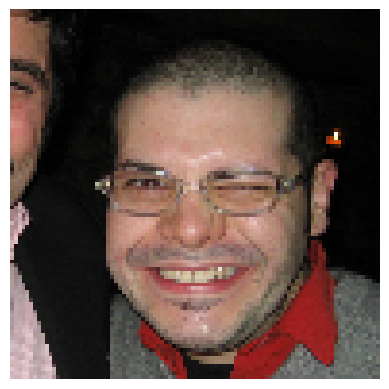

In [12]:

img = cv2.imread("./affectnet_dataset/Train/happy/ffhq_2713.png")

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis("off")

In [13]:
# STEP 2: Create an FaceLandmarker object.
base_options = python.BaseOptions(model_asset_path='face_landmarker_v2_with_blendshapes.task')
options = vision.FaceLandmarkerOptions(base_options=base_options,
                                       output_face_blendshapes=True,
                                       output_facial_transformation_matrixes=True,
                                       num_faces=1)
detector = vision.FaceLandmarker.create_from_options(options)

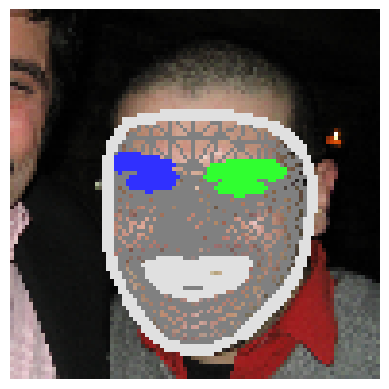

In [14]:
# STEP 3: Load the input image.
mp_image = mp.Image.create_from_file("./affectnet_dataset/Train/happy/ffhq_2713.png")

# STEP 4: Detect face landmarks from the input image.
detection_result = detector.detect(mp_image)

# STEP 5: Process the detection result. In this case, visualize it.
annotated_image = draw_landmarks_on_image(mp_image.numpy_view(), detection_result)
plt.imshow(annotated_image)
plt.axis("off")
plt.show()

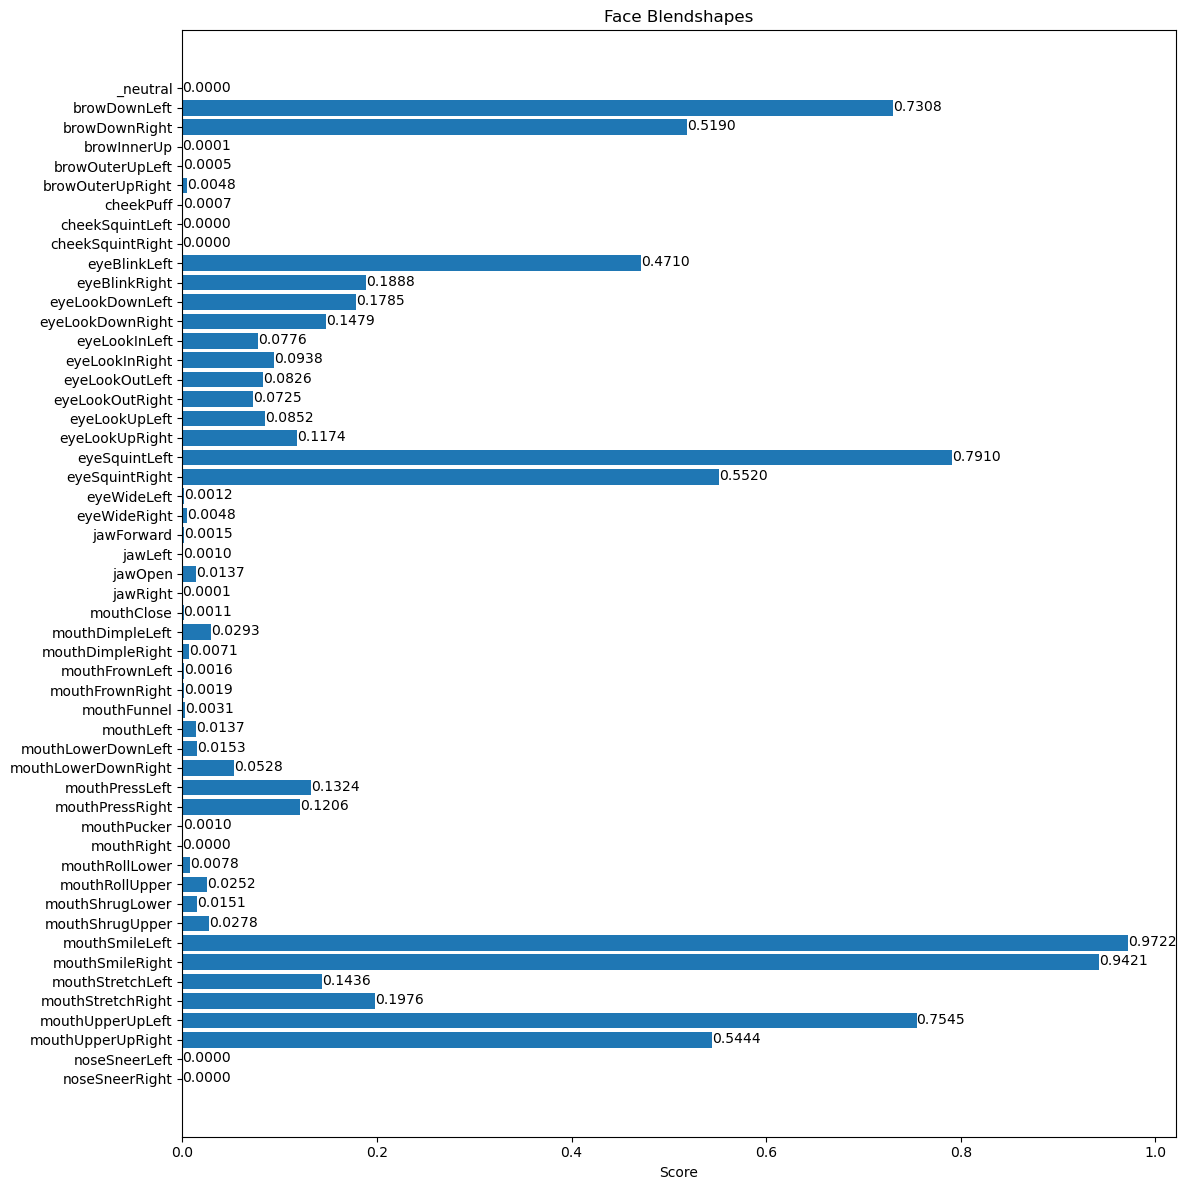

In [15]:
plot_face_blendshapes_bar_graph(detection_result.face_blendshapes[0])

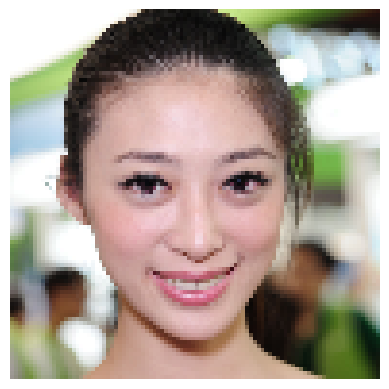

In [3]:
# !wget -q -O detector.tflite -q https://storage.googleapis.com/mediapipe-models/face_detector/blaze_face_short_range/float16/1/blaze_face_short_range.tflite
IMAGE_FILE = "./affectnet_dataset/Train/happy/ffhq_2720.png"

img = cv2.imread(IMAGE_FILE)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.axis("off")
plt.show()

In [4]:
MARGIN = 10  # pixels
ROW_SIZE = 10  # pixels
FONT_SIZE = 1
FONT_THICKNESS = 1
TEXT_COLOR = (255, 0, 0)  # red


def _normalized_to_pixel_coordinates(
    normalized_x: float, normalized_y: float, image_width: int,
    image_height: int) -> Union[None, Tuple[int, int]]:
  """Converts normalized value pair to pixel coordinates."""

  # Checks if the float value is between 0 and 1.
  def is_valid_normalized_value(value: float) -> bool:
    return (value > 0 or math.isclose(0, value)) and (value < 1 or
                                                      math.isclose(1, value))

  if not (is_valid_normalized_value(normalized_x) and
          is_valid_normalized_value(normalized_y)):
    # TODO: Draw coordinates even if it's outside of the image bounds.
    return None
  x_px = min(math.floor(normalized_x * image_width), image_width - 1)
  y_px = min(math.floor(normalized_y * image_height), image_height - 1)
  return x_px, y_px


def visualize(
    image,
    detection_result
) -> np.ndarray:
  """Draws bounding boxes and keypoints on the input image and return it.
  Args:
    image: The input RGB image.
    detection_result: The list of all "Detection" entities to be visualize.
  Returns:
    Image with bounding boxes.
  """
  annotated_image = image.copy()
  height, width, _ = image.shape

  for detection in detection_result.detections:
    # Draw bounding_box
    bbox = detection.bounding_box
    start_point = bbox.origin_x, bbox.origin_y
    end_point = bbox.origin_x + bbox.width, bbox.origin_y + bbox.height
    cv2.rectangle(annotated_image, start_point, end_point, TEXT_COLOR, 3)

    # Draw keypoints
    for keypoint in detection.keypoints:
      keypoint_px = _normalized_to_pixel_coordinates(keypoint.x, keypoint.y,
                                                     width, height)
      color, thickness, radius = (0, 255, 0), 2, 2
      cv2.circle(annotated_image, keypoint_px, thickness, color, radius)

    # Draw label and score
    category = detection.categories[0]
    category_name = category.category_name
    category_name = '' if category_name is None else category_name
    probability = round(category.score, 2)
    result_text = category_name + ' (' + str(probability) + ')'
    text_location = (MARGIN + bbox.origin_x,
                     MARGIN + ROW_SIZE + bbox.origin_y)
    cv2.putText(annotated_image, result_text, text_location, cv2.FONT_HERSHEY_PLAIN,
                FONT_SIZE, TEXT_COLOR, FONT_THICKNESS)

  return annotated_image

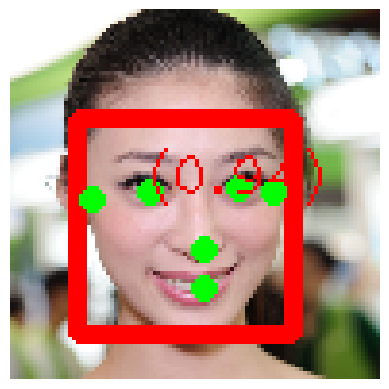

In [5]:
# STEP 2: Create an FaceDetector object.
base_options = python.BaseOptions(model_asset_path='detector.tflite')
options = vision.FaceDetectorOptions(base_options=base_options)
detector = vision.FaceDetector.create_from_options(options)

# STEP 3: Load the input image.
image = mp.Image.create_from_file(IMAGE_FILE)

# STEP 4: Detect faces in the input image.
detection_result = detector.detect(image)

# STEP 5: Process the detection result. In this case, visualize it.
image_copy = np.copy(image.numpy_view())
annotated_image = visualize(image_copy, detection_result)
plt.imshow(annotated_image)
plt.axis("off")
plt.show()